# Student Performance Prediction System using Machine Learning

This project predicts student academic performance based on factors like attendance, study hours, previous grades, and socio-economic background. 
Machine learning models such as Logistic Regression, Decision Trees, or Random Forest are used. 
    
# Objective:
Identify students at risk of failing 

# Outcome:
Helps institutions take preventive actions

# DATA INPUT MODULE

# data collection

In [1]:
import pandas as pd
df = pd.read_csv('student_performance.csv')

In [2]:
print(df.head())

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  


# DATA PROCESSING MODULE

# data preprocessing

In [29]:
#convert categorical data into numerical data A is the best grade F is bad grade
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 4}    #dictionary

In [4]:
df.isnull()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
999995,False,False,False,False,False,False
999996,False,False,False,False,False,False
999997,False,False,False,False,False,False
999998,False,False,False,False,False,False


In [5]:
df['grade_num'] = df['grade'].map(grade_map)

In [6]:
print(df['grade_num'])

0         0
1         1
2         0
3         0
4         0
         ..
999995    0
999996    0
999997    0
999998    0
999999    0
Name: grade_num, Length: 1000000, dtype: int64


# Exploratory Data analysis(EDA)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

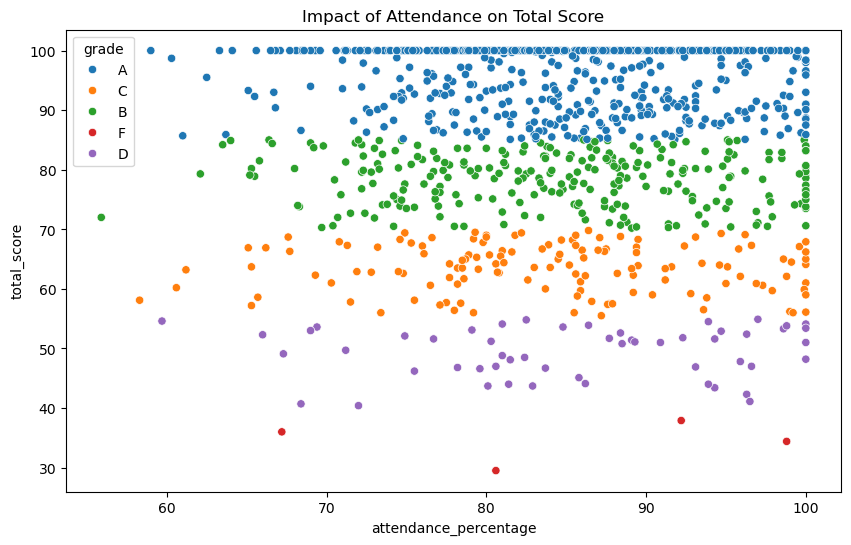

In [8]:
# Visualizing Attendance vs Total Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(1000), x='attendance_percentage', y='total_score', hue='grade')
plt.title('Impact of Attendance on Total Score')
plt.show()

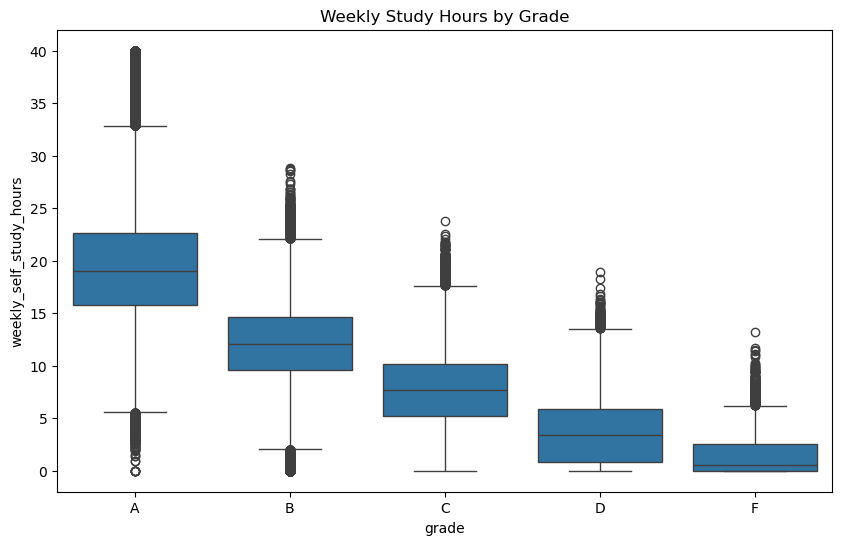

In [9]:
# Boxplot: Study Hours vs Grades
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='grade', y='weekly_self_study_hours', order=['A', 'B', 'C', 'D', 'F'])
plt.title('Weekly Study Hours by Grade')
plt.show()

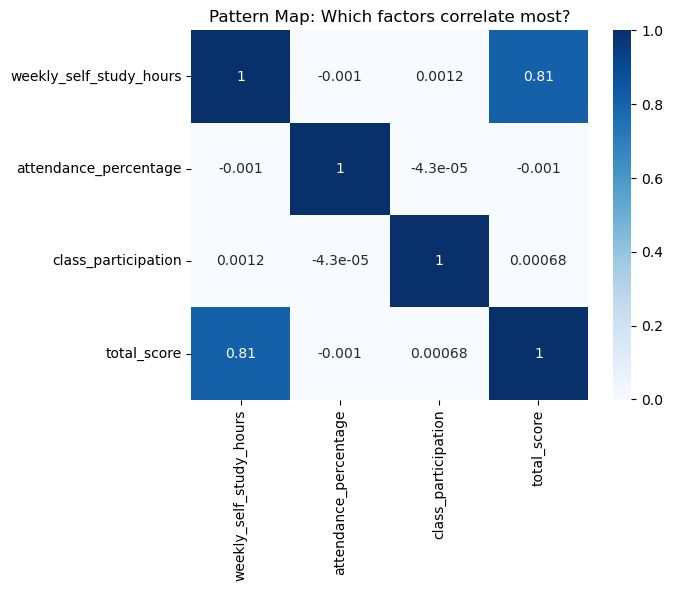

In [10]:
numeric_columns = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']]
correlation = numeric_columns.corr()
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Pattern Map: Which factors correlate most?')
plt.show()

# Feature selection

In [11]:
X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']]
y = df['grade_num']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# MODEL TRAINING MODULE

# model selection and model training

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [15]:
#logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [16]:
# 2. Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [17]:
# 3. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [18]:
svm = SVC(kernel='linear')
svm.fit(X_train[:5000], y_train[:5000])

SVC(kernel='linear')

# PREDICTION MODULE

# prediction & evaluation

In [20]:
print("--- Model Accuracy Results ---")
print(f"Logistic Regression: {accuracy_score(y_test, lr.predict(X_test)):.2%}")
print(f"Decision Tree: {accuracy_score(y_test, dt.predict(X_test)):.2%}")
print(f"Naive Bayes:{accuracy_score(y_test, nb.predict(X_test)):.2%}")
print(f"SVM (Linear):{accuracy_score(y_test[:1000], svm.predict(X_test[:1000])):.2%}")

--- Model Accuracy Results ---
Logistic Regression: 69.69%
Decision Tree: 60.91%
Naive Bayes:69.65%
SVM (Linear):67.50%


In [21]:
final_predictions = lr.predict(X_test)

In [22]:
# 2. Create a clean results table
results_df = X_test.copy()
results_df['Predicted_Grade_Num'] = final_predictions

In [23]:
# Map numbers back to Letters for the report
reverse_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
results_df['Predicted_Grade'] = results_df['Predicted_Grade_Num'].map(reverse_map)

In [24]:
at_risk_students = results_df[results_df['Predicted_Grade'].isin(['D', 'F'])]

In [27]:
print(f"\nTotal Students Identified as 'At-Risk': {len(at_risk_students)}")
print("Top 5 people who need attention")
print(at_risk_students.head())         


Total Students Identified as 'At-Risk': 6192
Top 5 people who need attention
        weekly_self_study_hours  attendance_percentage  class_participation  \
55399                       0.9                   87.0                  5.4   
943378                      0.4                   84.8                  4.2   
67898                       0.0                   69.4                  7.5   
837523                      2.0                   86.2                 10.0   
889145                      0.8                   82.6                  3.8   

        Predicted_Grade_Num Predicted_Grade  
55399                     3               D  
943378                    3               D  
67898                     3               D  
837523                    3               D  
889145                    3               D  


# RESULT VISUALIZATION MODULE

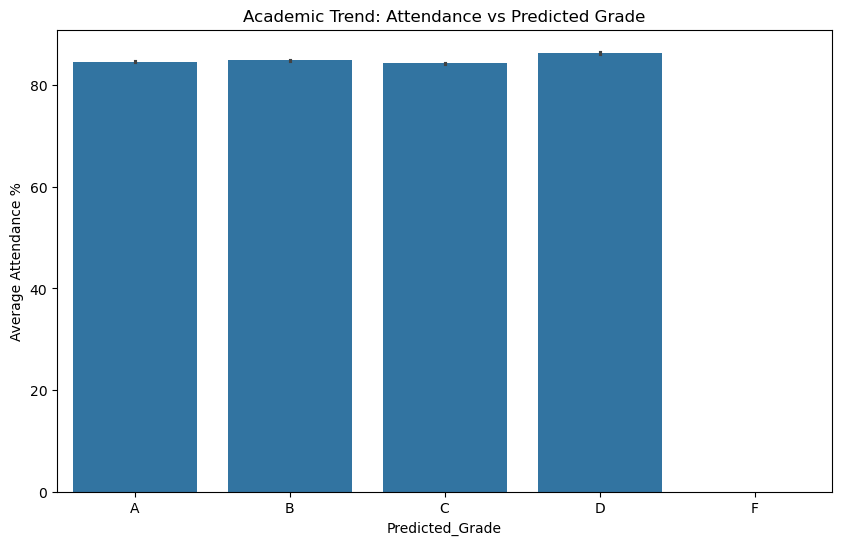

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Predicted_Grade', y='attendance_percentage', data=results_df, order=['A', 'B', 'C', 'D', 'F'])
plt.title('Academic Trend: Attendance vs Predicted Grade')
plt.ylabel('Average Attendance %')
plt.show()